In [1]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import torch

df = pd.read_csv("Excel/merged_dataset.csv")

print(df.shape)


(3600, 15)


In [3]:
print(df.columns)


Index(['image', 'labels', 'complex1', 'complex2', 'complex3', 'complex4',
       'blurred', 'rain', 'fog', 'snow', 'night', 'occluded', 'truncated',
       'no_annotation', 'lp_blurred'],
      dtype='object')


In [4]:

df.head()

,image,labels,complex1,complex2,complex3,complex4,blurred,rain,fog,snow,night,occluded,truncated,no_annotation,lp_blurred
0,1000.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,551.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,552.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,553.jpg,complex1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,554.jpg,complex1,1,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
label_cols = df.columns[2:]  # skip image + labels

label_counts = df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

complex1         2559
lp_blurred       1404
no_annotation     736
blurred           582
complex2          453
complex3          297
truncated         165
occluded          153
complex4          124
night             100
rain               50
fog                36
snow                0
dtype: int64


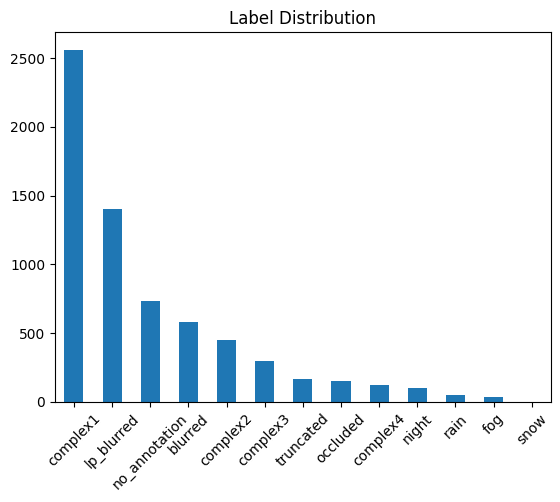

In [6]:
import matplotlib.pyplot as plt

label_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

In [7]:
total = len(df)

imbalance = (total - label_counts) / label_counts
print(imbalance.sort_values(ascending=False))

snow                   inf
fog              99.000000
rain             71.000000
night            35.000000
complex4         28.032258
occluded         22.529412
truncated        20.818182
complex3         11.121212
complex2          6.947020
blurred           5.185567
no_annotation     3.891304
lp_blurred        1.564103
complex1          0.406800
dtype: float64


In [8]:
print(label_counts[label_counts == 0])

snow    0
dtype: int64


In [9]:
df = df.drop(columns=['snow'])

In [10]:
df.head()

,image,labels,complex1,complex2,complex3,complex4,blurred,rain,fog,night,occluded,truncated,no_annotation,lp_blurred
0,1000.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0
1,551.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0
2,552.jpeg,complex1,1,0,0,0,0,0,0,0,0,0,0,0
3,553.jpg,complex1,1,0,0,0,0,0,0,0,0,0,0,0
4,554.jpg,complex1,1,0,0,0,0,0,0,0,0,0,0,0


In [11]:
df['no_annotation'].value_counts()

no_annotation
0    2864
1     736
Name: count, dtype: int64

In [12]:
df.columns

Index(['image', 'labels', 'complex1', 'complex2', 'complex3', 'complex4',
       'blurred', 'rain', 'fog', 'night', 'occluded', 'truncated',
       'no_annotation', 'lp_blurred'],
      dtype='object')

In [13]:
pip install seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


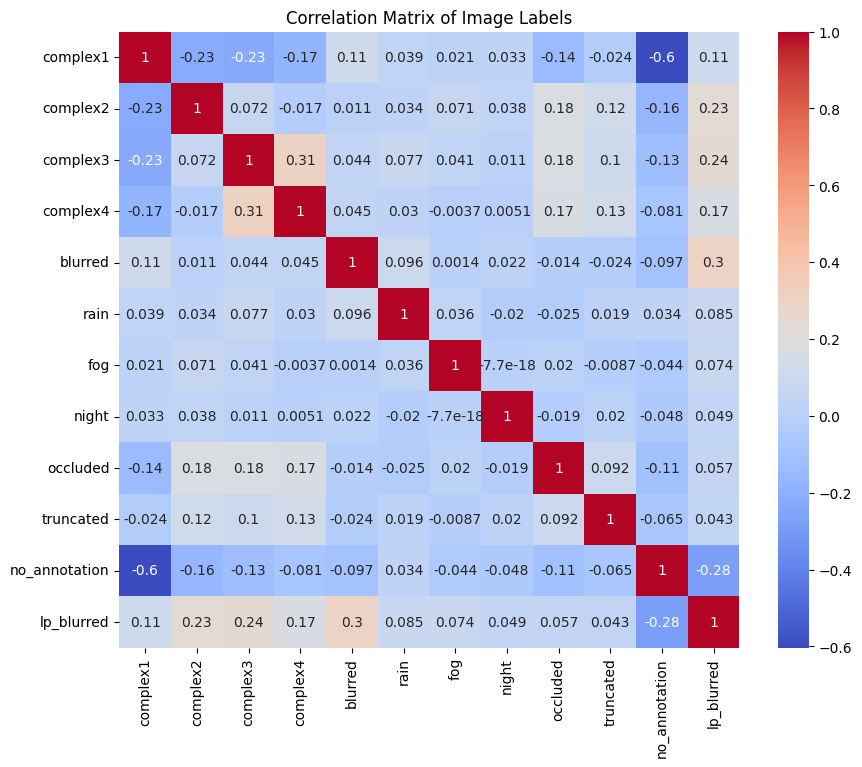

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt  #

label_cols = ['complex1', 'complex2', 'complex3', 'complex4', 'blurred', 'rain', 'fog', 'night', 'occluded', 'truncated', 'no_annotation', 'lp_blurred']

# Create correlation matrix
corr = df[label_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Image Labels")
plt.show()


In [15]:
df['image'].duplicated().sum()

np.int64(0)

In [16]:
label_cols = [col for col in df.columns if col not in ['image', 'labels']]


In [17]:
total_samples = len(df)

In [18]:
label_counts = df[label_cols].sum()

In [19]:
pos_weight = (total_samples - label_counts) / label_counts

In [20]:
pos_weight = pos_weight.replace([float('inf')], 0)

In [21]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
pos_weight_tensor = torch.tensor(pos_weight.values, dtype=torch.float32)

In [23]:
pos_weight_tensor = torch.clamp(pos_weight_tensor, max=30)

In [24]:
print("Label Counts:\n", label_counts)
print("\nPos Weights:\n", pos_weight)
print("\nTensor:\n", pos_weight_tensor)

Label Counts:
 complex1         2559
complex2          453
complex3          297
complex4          124
blurred           582
rain               50
fog                36
night             100
occluded          153
truncated         165
no_annotation     736
lp_blurred       1404
dtype: int64

Pos Weights:
 complex1          0.406800
complex2          6.947020
complex3         11.121212
complex4         28.032258
blurred           5.185567
rain             71.000000
fog              99.000000
night            35.000000
occluded         22.529412
truncated        20.818182
no_annotation     3.891304
lp_blurred        1.564103
dtype: float64

Tensor:
 tensor([ 0.4068,  6.9470, 11.1212, 28.0323,  5.1856, 30.0000, 30.0000, 30.0000,
        22.5294, 20.8182,  3.8913,  1.5641])


In [25]:
df.to_csv("cleaned_dataset.csv", index=False)

In [26]:
df['labels'] = df['labels'].apply(
    lambda x: ','.join([l for l in x.split(',') if l != 'snow'])
)

In [27]:
import numpy as np
np.save("pos_weights.npy", pos_weight_tensor.numpy())